#21 Clusterring Income Spent Using Hierarchial clusterring

## Importing the basic libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset from Local Directory

In [19]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset (1).csv


## Importing the dataset

In [20]:
dataset = pd.read_csv('dataset.csv')

# *Exploratory Data Analysis (EDA)*


Missing Values:
 CustomerID            0
Gender                0
Age                   0
Annual Income (k$)    0
Spending Score        0
dtype: int64

Data Types:
 CustomerID             int64
Gender                object
Age                    int64
Annual Income (k$)     int64
Spending Score         int64
dtype: object


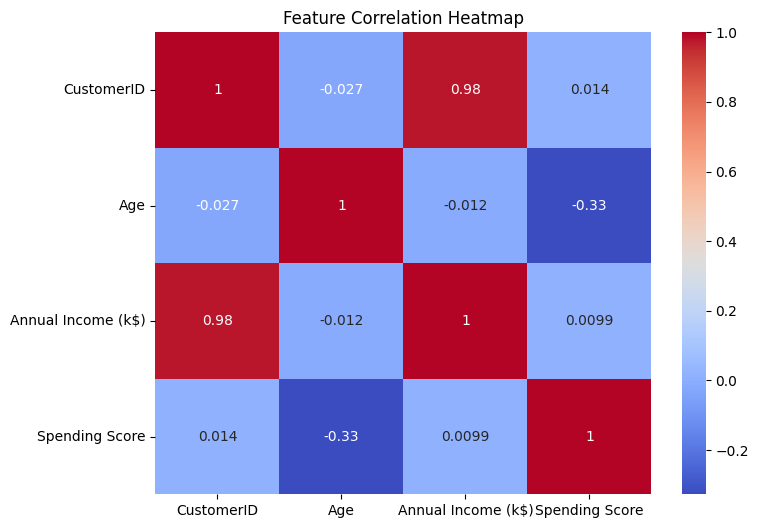

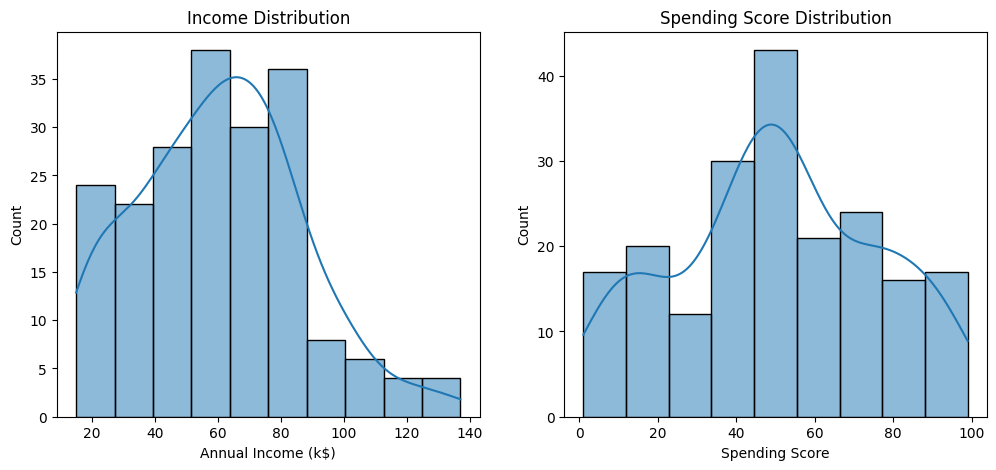

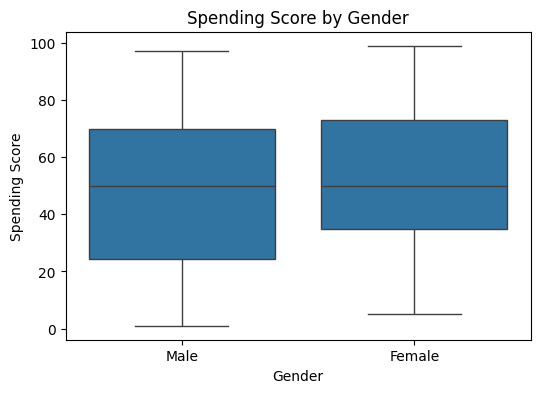

In [21]:
print("\nMissing Values:\n", dataset.isnull().sum())

print("\nData Types:\n", dataset.dtypes)

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(dataset.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Distribution plots
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(dataset['Annual Income (k$)'], kde=True)
plt.title("Income Distribution")

plt.subplot(1,2,2)
sns.histplot(dataset['Spending Score'], kde=True)
plt.title("Spending Score Distribution")

plt.show()

# Gender vs Spending
plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='Spending Score', data=dataset)
plt.title("Spending Score by Gender")
plt.show()

# *Feature scaling*

In [22]:
# Selecting only important features
X_vis = dataset.iloc[:, [3,4]].values

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X_vis)

### Summarize Dataset

In [23]:
print(dataset.shape)
print(dataset.describe())
print(dataset.head(5))

(200, 5)
       CustomerID         Age  Annual Income (k$)  Spending Score
count  200.000000  200.000000          200.000000      200.000000
mean   100.500000   38.850000           60.560000       50.200000
std     57.879185   13.969007           26.264721       25.823522
min      1.000000   18.000000           15.000000        1.000000
25%     50.750000   28.750000           41.500000       34.750000
50%    100.500000   36.000000           61.500000       50.000000
75%    150.250000   49.000000           78.000000       73.000000
max    200.000000   70.000000          137.000000       99.000000
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score
0           1    Male   19                  15              39
1           2    Male   21                  15              81
2           3  Female   20                  16               6
3           4  Female   23                  16              77
4           5  Female   31                  17              40


### Label Encoding

In [24]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()
dataset['Gender'] = label_encoder.fit_transform(dataset['Gender'])
print("\nEncoded Gender Values:\n", dataset['Gender'].value_counts())
dataset.head()
# Selecting only relevant features
X = dataset[['Annual Income (k$)', 'Spending Score']].values


Encoded Gender Values:
 Gender
0    112
1     88
Name: count, dtype: int64


# *scaling*

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Dendrogram Data visualization

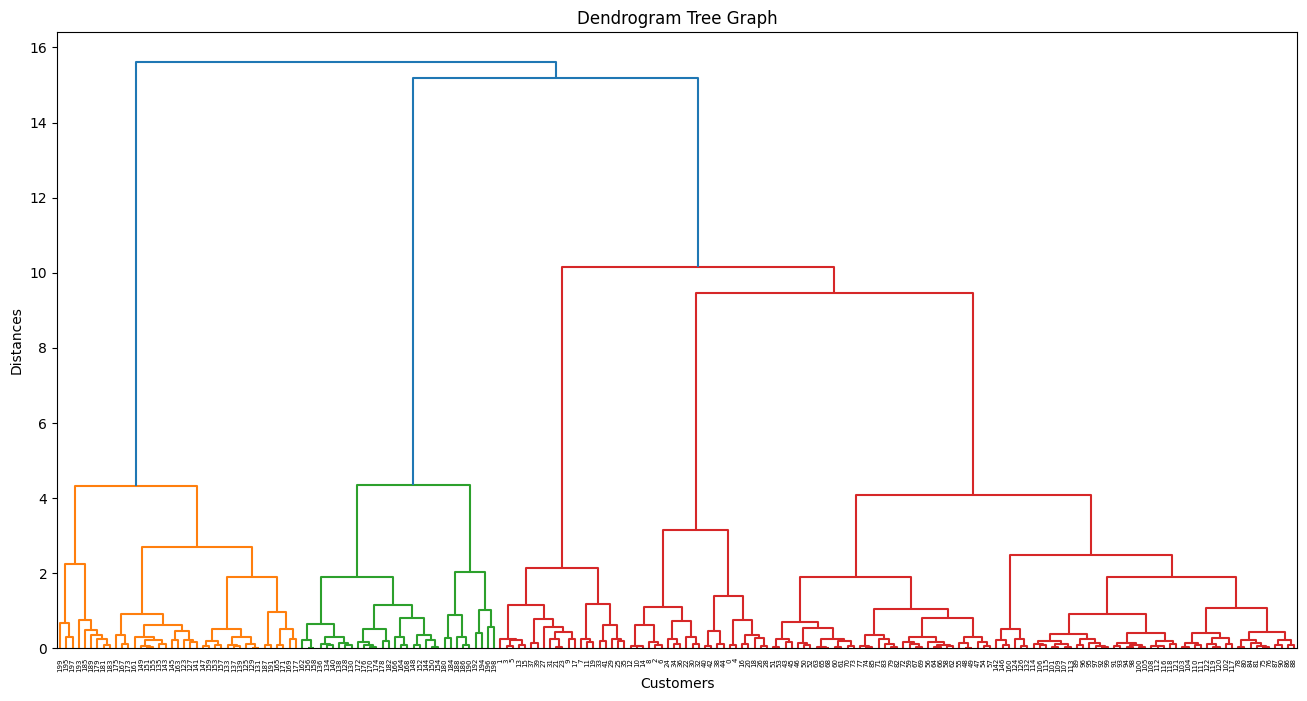

In [26]:
import scipy.cluster.hierarchy as clus
import matplotlib.pyplot as plt

plt.figure(1, figsize = (16 ,8))
dendrogram = clus.dendrogram(clus.linkage(X_scaled, method="ward"))

plt.title('Dendrogram Tree Graph')
plt.xlabel('Customers')
plt.ylabel('Distances')
plt.show()

### Fitting the Hierarchial clustering to the dataset with n=5

In [27]:
# Hierarchical Clustering

from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_means = model.fit_predict(X)

print(y_means)

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 1 2 0 2 1 2
 0 2 0 2 0 2 0 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]


# *SILHOUETTE SCORE*

In [28]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, y_means)
print("\nSilhouette Score:", score)


Silhouette Score: 0.5538089226688662


# *cluster quality*

In [29]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, y_means)
print("Silhouette Score:", score)

Silhouette Score: 0.5529945955148897


In [30]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

### Visualizing the number of clusters n=5

Cluster 1: Customers with Medium Income and Medium Spending

Cluster 2: Customers with High Income and High Spending

Cluster 3: Customers with Low Income and Low Spending

Cluster 4: Customers with High Income and Low Spending

Cluster 5: Customers with Low Income and High Spending

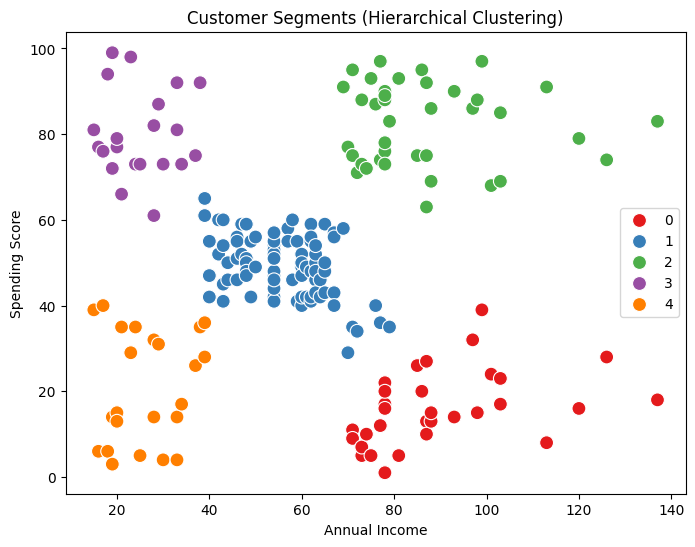

In [31]:
# Convert to DataFrame for better plotting
df_vis = pd.DataFrame(X, columns=['Income', 'Spending'])
df_vis['Cluster'] = y_means

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_vis,
    x='Income',
    y='Spending',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("Customer Segments (Hierarchical Clustering)")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.legend()
plt.show()